# Projet 5MA-OSI : Transfert d'organes en domino sous incertitudes

## Introduction

Malgré l'augmentation croissante du nombre de transplantations d'organes effectuées chaque année (environ 6000 en 2017 dont 3782 transplantations de reins), la demande reste en perpétuelle augmentation. Ainsi 6000 organes, dont 3782 reins, ont été transplantés en 2017, mais il y avait encore 24000 personnes en attente d'un organe la même année. Les organes transplantés peuvent provenir d'un donneur décédé ou, dans le cas des reins et du foie, d'un donneur vivant consentant, le plus souvent membre de la famille du patient. Hélas, même si un proche accepte de prendre ce risque pour sa santé, il ne sera pas forcément compatible avec le patient. Pour cette raison, les pratiques médicales et les législations évoluent dans de nombreux pays afin de permettre la mise en place d'un programme d'échange de dons d'organes.

L'exemple le plus simple d'échange de don d'organes est celui où deux patients $P_1$ et $P_2$ sont accompagnés de donneurs $D_1$ et $D_2$. Les patients sont supposés incompatibles avec les donneurs qui les accompagnent, mais on suppose que $D_1$ est compatible avec $P_2$ et $D_2$ avec $P_1$. Il est alors possible de transplanter un organe de $D_1$ vers $P_2$ et de $D_2$ vers $P_1$ avec le consentement de tous et en suivant la procédure légale.

Plus généralement, un cycle d'échange d'organes associe $k$ paires de patient-donneur $(P_{i_1},D_{i_1}), \dots, (P_{i_k},D_{i_k})$ de sorte que $D_{i_l}$ donne à $P_{i_{l+1}}$ pour $l=1,\dots,k-1$ et $D_{i_k}$ donne à $P_{i_1}$.
Par ailleurs, le point essentiel est que les transferts soient tous réalisés en même temps et dans le même hôpital pour éviter qu'une rétractation de dernière minute ne lèse un patient et son donneur, et que les patients et donneurs venus ensemble et leur famille puissent se soutenir émotionnellement durant l'hospitalisation. 
Pour cette raison, le nombre d'échanges prenant place au sein d'un même cycle est nécessairement limité. En pratique, l'organisation d'un cycle de trois paires est déjà une épreuve pour le personnel d'un hôpital, et le plus grand cycle ayant jamais eu lieu a a impliqué six patients et donneurs.

Dans ce projet, nous prendrons le point de vue de l'organisme national responsable de la gestion du programme d'échange d'organes. 
À chaque phase d'échange, l'objectif de cet organisme est de choisir un ensemble de cycles d'échanges entre paires compatibles afin de maximiser le nombre de patients recevant un organe. Dans certains cas, on peut aussi donner une priorité à certains patients en fonction de la gravité de leur état ou de la durée de leur attente. 
Pour cela, on pourra attribuer des poids différents à chaque patient et maximiser la somme des poids des patients recevant un organe. 

## Étude du problème déterministe


### Jeux de données

Tous vos tests seront basés sur les jeux de données de la [PrefLib](https://www.preflib.org/dataset/00036). Ces jeux de données ne correspondent pas à des programmes d'échanges d'organes réels pour des raisons de confidentialité, mais ils reproduisent la structure des données réelles plus fidèlement que les données aléatoires utilisées pour le projet de RO. Ils 
sont constituées d'informations individuelles et d'un graphe de compatibilité. Chaque fichier .wmd décrit un graphe de compatibilité orienté, $G=(V,A)$, où chaque sommet de $V$ représente une paire patient-donneur et où un arc entre deux paires $(P_k,D_k)$ et $(P_l,D_l)$ signifie que $D_k$ est compatible avec $P_l$. La compatibilité est obtenue à partir des données biologiques individuelles (e.g., les groupes sanguins) et d'un _test croisé_ lors duquel des biologistes mettent en présence des tissus d'un malade et d'un donneur supposé. Chaque fichier est composé comme suit :  
- les 11 premières ligne contiennent diverses informations sur le fichier, dont le nombre de sommets ($n$) et le nombre d'arcs ($m$),
- les $n$ lignes suivantes nomment les sommets (un sommet par paire),
- les $m$ lignes restantes contiennent les arcs du graphe et le poids de chaque arc. Le poids de chaque arc indique l'urgence de la situation du malade de la paire destination. 

Je fournis ci-dessous une fonction permettant de lire les fichiers .wmd et retournant un graphe de compatibilité pondéré par les poids de chaque patient. Pour vous aider à vous lancer, je fournis déjà quelques instances en accompagnement de ce sujet sur Moodle. Elles contiennent un nombre croissant de paires patient-donneur allant de 16 à 512.

In [2]:
using Pkg
Pkg.add("Plots")
Pkg.add("BenchmarkProfiles")

    Updating registry at `C:\Users\Yilon\.julia\registries\General.toml`
   Resolving package versions...
   Installed libdecor_jll ───────────────── v0.2.2+0
   Installed RelocatableFolders ─────────── v1.0.1
   Installed GR_jll ─────────────────────── v0.73.18+0
   Installed Contour ────────────────────── v0.6.3
   Installed LoggingExtras ──────────────── v1.2.0
   Installed Xorg_xkbcomp_jll ───────────── v1.4.7+0
   Installed Xorg_xcb_util_image_jll ────── v0.4.1+0
   Installed Grisu ──────────────────────── v1.0.2
   Installed ConcurrentUtilities ────────── v2.5.0
   Installed PlotUtils ──────────────────── v1.4.4
   Installed RecipesPipeline ────────────── v0.6.12
   Installed Xorg_xcb_util_jll ──────────── v0.4.1+0
   Installed OpenSSL ────────────────────── v1.6.0
   Installed Xorg_libSM_jll ─────────────── v1.2.6+0
   Installed Xorg_xcb_util_wm_jll ───────── v0.4.2+0
   Installed HTTP ───────────────────────── v1.10.19
   Installed Xorg_libXinerama_jll ───────── v1.1.6+0
   Ins

In [1]:
# Include the necessary packages
using Random, Graphs, JuMP, HiGHS, DelimitedFiles, Distributions, Plots, BenchmarkProfiles
include("KEP_readfile.jl")

read_wmd_file

In [4]:
# Exemple d'utilisation de la fonction supposant que les fichiers sont dans le dossier data_KEP
G, edge_weight = read_wmd_file("data_KEP/KEP_001.wmd");
println("Number of vertices: ", nv(G));
println("Number of arcs: ", ne(G));
println("List of arcs with weights:")
for e in edges(G)
    print("($(e.src),$(e.dst)):$(edge_weight[e.src,e.dst]), ");
end

Number of vertices: 16
Number of arcs: 59
List of arcs with weights:
(1,5):1.0, (1,6):1.0, (2,1):1.0, (2,3):1.0, (2,11):1.0, (2,12):1.0, (3,5):1.0, (3,8):1.0, (4,1):1.0, (4,3):1.0, (4,11):1.0, (6,1):1.0, (6,3):1.0, (6,11):1.0, (7,1):1.0, (7,3):1.0, (7,11):1.0, (7,12):1.0, (8,1):1.0, (8,3):1.0, (8,11):1.0, (9,1):1.0, (9,3):1.0, (9,11):1.0, (9,12):1.0, (10,1):1.0, (10,2):1.0, (10,3):1.0, (10,5):1.0, (10,8):1.0, (10,9):1.0, (10,11):1.0, (10,12):1.0, (10,14):1.0, (10,15):1.0, (10,16):1.0, (12,1):1.0, (12,3):1.0, (12,11):1.0, (13,2):1.0, (13,3):1.0, (13,5):1.0, (13,7):1.0, (13,8):1.0, (13,9):1.0, (13,11):1.0, (13,14):1.0, (13,15):1.0, (13,16):1.0, (14,1):1.0, (14,3):1.0, (14,11):1.0, (14,12):1.0, (15,1):1.0, (15,3):1.0, (15,11):1.0, (16,5):1.0, (16,6):1.0, (16,8):1.0, 

### Formulations compactes

Dans le cadre du TD/TP du cours de Recherche Opérationnelle, il vous a été demandé de coder trois formulations PLNE, à savoir :
- celle sans contrainte sur la longueur des cycles
- celle avec des cycles de taille 2
- celle avec la décomposition par hôpital pour des cycles de taille 2 à 6.

J'ai recopié la correction distribuée sur Moodle dans le fichier formulation_compactes.jl. Je l'inclus ci dessous. Afin de prendre le sujet en main, comparer les solutions des 3 modèles sur un ensemble de jeux de données bien choisis. Analyser les résultats d'un point de vue informatique, pratique et sociétal.

In [77]:
# inclusion des fonctions de résolution des formulations compactes
include("formulations_compactes.jl")

# tests de bon fonctionnement sur le petit graphe importé plus haut
# solve_cycle_infini(G, edge_weight);
# solve_cycle_2(G, edge_weight);
G, edge_weight = read_wmd_file("data_KEP/KEP_111.wmd");
K = 4
solve_cycle_K(G, edge_weight, K);


-------------------------------
Résolution du modèle avec cycle de taille au plus 4

Statut de la résolution : OPTIMAL
Durée de la résolution : 50.4937479
Nombre de transferts réalisés : 83
Liste des transferts réalisés :
3 -> 83 ; 4 -> 101 ; 8 -> 104 ; 10 -> 11 ; 11 -> 105 ; 12 -> 87 ; 14 -> 23 ; 15 -> 126 ; 16 -> 19 ; 19 -> 109 ; 23 -> 14 ; 24 -> 71 ; 25 -> 120 ; 29 -> 64 ; 31 -> 97 ; 32 -> 76 ; 33 -> 51 ; 34 -> 45 ; 35 -> 99 ; 36 -> 111 ; 39 -> 84 ; 40 -> 62 ; 41 -> 103 ; 43 -> 121 ; 45 -> 34 ; 47 -> 78 ; 48 -> 107 ; 50 -> 61 ; 51 -> 33 ; 52 -> 55 ; 53 -> 75 ; 54 -> 70 ; 55 -> 52 ; 58 -> 41 ; 59 -> 8 ; 61 -> 127 ; 62 -> 40 ; 64 -> 67 ; 65 -> 115 ; 67 -> 29 ; 68 -> 124 ; 69 -> 53 ; 70 -> 116 ; 71 -> 24 ; 72 -> 94 ; 75 -> 69 ; 76 -> 32 ; 77 -> 85 ; 78 -> 47 ; 81 -> 92 ; 83 -> 3 ; 84 -> 39 ; 85 -> 77 ; 86 -> 102 ; 87 -> 12 ; 88 -> 91 ; 91 -> 88 ; 92 -> 81 ; 94 -> 72 ; 95 -> 123 ; 96 -> 98 ; 97 -> 31 ; 98 -> 96 ; 99 -> 35 ; 101 -> 4 ; 102 -> 86 ; 103 -> 58 ; 104 -> 59 ; 105 -> 10 ; 106

### Génération de colonnes

L'objectif de cette partie du projet est de coder une méthode de génération de colonnes pour le problème de dons d'organes en dominos (KEP pour Kidney Exchange Problem en anglais) sans incertitudes. Votre code s'appuiera sur les éléments vus en CM et leur application au KEP vue en TD. Pour compléter cette présentation, [une page de la documentation de JuMP](https://jump.dev/JuMP.jl/stable/tutorials/algorithms/cutting_stock_column_generation/) est dédiée à la génération de colonnes. Elle vous offre une autre entrée en matière sur la question.

1. Coder une fonction résolvant le modèle par cycles après énumération de touts les cycles de taille $K$ ou moins. Tester pour $K=2,3,4$.
2. Coder une méthode de génération de colonnes pour résoudre la relaxation linéaire de la formulation par cycles. Vous implémenterez deux versions de la fonction de _pricing_ (résolution du sous-problème) : une ou le sous-problème est formulé à l'aide d'un ensemble de PLNE, et une ou le sous-problème est résolu par un algorithme de plus long chemin.
3. Coder une fonction qui résout le problème de dons en dominos de façon approchée à l'aide de l'heuristique de génération de colonnes décrite en CM.


## 1. brute force approach

In [82]:
include("brute_force_approach.jl")
K = 4
G, edge_weight = read_wmd_file("data_KEP/KEP_111.wmd");
#C_K = enumerate_cycles(G,K)

brut_force(G,K)


-------------------------------
Brute force resolution of the KEP problem with K = 4 

Resolution status : OPTIMAL
computation time : 133.321195
Number of performed exchanges  : 82.99999999999999
List of performed exchanges :

*** Cycle chosen: 
	 3 -> 19 -> 109 -> 114
*** Cycle chosen: 
	 4 -> 101 -> 68
*** Cycle chosen: 
	 8 -> 61
*** Cycle chosen: 
	 11 -> 15
*** Cycle chosen: 
	 12 -> 121 -> 43 -> 124
*** Cycle chosen: 
	 14 -> 46
*** Cycle chosen: 
	 16 -> 115
*** Cycle chosen: 
	 24 -> 71
*** Cycle chosen: 
	 25 -> 75
*** Cycle chosen: 
	 29 -> 64 -> 67
*** Cycle chosen: 
	 31 -> 80
*** Cycle chosen: 
	 32 -> 96 -> 84
*** Cycle chosen: 
	 39 -> 72
*** Cycle chosen: 
	 40 -> 104
*** Cycle chosen: 
	 41 -> 103 -> 70
*** Cycle chosen: 
	 44 -> 126
*** Cycle chosen: 
	 45 -> 87 -> 119 -> 59
*** Cycle chosen: 
	 48 -> 62
*** Cycle chosen: 
	 49 -> 54
*** Cycle chosen: 
	 50 -> 95
*** Cycle chosen: 
	 52 -> 58 -> 69
*** Cycle chosen: 
	 53 -> 65
*** Cycle chosen: 
	 56 -> 85
*** Cycle

## 2,3. Column generation for Kidney Exchange Problems

In [9]:
include("tests.jl")
include("formulations_compactes.jl")
include("brute_force_approach.jl")

K = 4
times = [Vector{Float64}() for i in 1:4]

#KEP_001
G, edge_weight = read_wmd_file("data_KEP/KEP_001.wmd");

test_ILP = KEP_test("data_KEP/KEP_001.wmd"; SP_method="ILP")
test_Bellman = KEP_test("data_KEP/KEP_001.wmd"; SP_method="Bellmann")

solve_KEP(test_ILP) #First call to the function to avoid false time
solve_KEP(test_Bellman) #First call to the function to avoid false time

timer_ILP = @timed solve_KEP(test_ILP; verb=1)
timer_Bellman = @timed solve_KEP(test_Bellman; verb=1)
timer_compact = @timed solve_cycle_K(G, edge_weight, K)
timer_brute = @timed brut_force(G,K)

push!(times[1], timer_ILP.time)
push!(times[2], timer_Bellman.time)
push!(times[3], timer_compact.time)
push!(times[4], timer_brute.time)

#KEP_031
G, edge_weight = read_wmd_file("data_KEP/KEP_031.wmd");

test_ILP = KEP_test("data_KEP/KEP_031.wmd"; SP_method="ILP")
test_Bellman = KEP_test("data_KEP/KEP_031.wmd"; SP_method="Bellmann")

timer_ILP = @timed solve_KEP(test_ILP; verb=1)
timer_Bellman = @timed solve_KEP(test_Bellman; verb=1)
timer_compact = @timed solve_cycle_K(G, edge_weight, K)
timer_brute = @timed brut_force(G,K)

push!(times[1], timer_ILP.time)
push!(times[2], timer_Bellman.time)
push!(times[3], timer_compact.time)
push!(times[4], timer_brute.time)

#KEP_071
G, edge_weight = read_wmd_file("data_KEP/KEP_071.wmd");

test_ILP = KEP_test("data_KEP/KEP_071.wmd"; SP_method="ILP")
test_Bellman = KEP_test("data_KEP/KEP_071.wmd"; SP_method="Bellmann")

timer_ILP = @timed solve_KEP(test_ILP; verb=1)
timer_Bellman = @timed solve_KEP(test_Bellman; verb=1)
timer_compact = @timed solve_cycle_K(G, edge_weight, K)
timer_brute = @timed brut_force(G,K)

push!(times[1], timer_ILP.time)
push!(times[2], timer_Bellman.time)
push!(times[3], timer_compact.time)
push!(times[4], timer_brute.time)

#KEP_111
G, edge_weight = read_wmd_file("data_KEP/KEP_111.wmd");

test_ILP = KEP_test("data_KEP/KEP_111.wmd"; SP_method="ILP")
test_Bellman = KEP_test("data_KEP/KEP_111.wmd"; SP_method="Bellmann")

timer_ILP = @timed solve_KEP(test_ILP; verb=1)
timer_Bellman = @timed solve_KEP(test_Bellman; verb=1)
timer_compact = @timed solve_cycle_K(G, edge_weight, K)
timer_brute = @timed brut_force(G,K)

push!(times[1], timer_ILP.time)
push!(times[2], timer_Bellman.time)
push!(times[3], timer_compact.time)
push!(times[4], timer_brute.time)

#KEP_151
test_ILP = KEP_test("data_KEP/KEP_151.wmd"; SP_method="ILP")
test_Bellman = KEP_test("data_KEP/KEP_151.wmd"; SP_method="Bellmann")

timer_ILP = @timed solve_KEP(test_ILP; verb=1)
timer_Bellman = @timed solve_KEP(test_Bellman; verb=1)

push!(times[1], timer_ILP.time)
push!(times[2], timer_Bellman.time)
push!(times[3], -1)
push!(times[4], -1)

#KEP_191
test_ILP = KEP_test("data_KEP/KEP_191.wmd"; SP_method="ILP")
test_Bellman = KEP_test("data_KEP/KEP_191.wmd"; SP_method="Bellmann")

timer_ILP = @timed solve_KEP(test_ILP; verb=1)
timer_Bellman = @timed solve_KEP(test_Bellman; verb=1)

push!(times[1], timer_ILP.time)
push!(times[2], timer_Bellman.time)
push!(times[3], -1)
push!(times[4], -1)


-------------------
outneigbours graph built in 2.34e-5 seconds
	 -> invalids subproblems (G_o_prime without any path): [2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
-------------------
	 iter 1 / 500z_o := 4.0
	 iter 2 / 500z_o := 0.0
z_o := 0.0
| Column generation (linear) : optimum found |

	 - number of transfert perfomed : 4.0
	 - transfert performed: [[1, 6], [8, 3]]


C_K_k[α .> 0.0] = [[1, 6], [8, 3]]
| Integer solution : optimum found |

	 - number of transfert perfomed : 4
	 - transfert performed: [[1, 6], [8, 3]]


	 iter 2 / 500============================================== 
| Column generation (linear) : optimum found |

	 - number of transfert perfomed : 4.0
	 - transfert performed: [[3, 8], [1, 6]]


C_K_k[α .> 0.0] = [[3, 8], [1, 6]]
| Integer solution : optimum found |

	 - number of transfert perfomed : 4
	 - transfert performed: [[3, 8], [1, 6]]



-------------------------------
Résolution du modèle avec cycle de taille au plus 4

Statut de la résolution : OPTIM

6-element Vector{Float64}:
   0.1872767
   0.1468828
   5.1370779
 140.7201428
  -1.0
  -1.0

In [13]:
#KEP 1024
test_Bellman = KEP_test("data_KEP/00036-00000232.wmd"; SP_method="Bellmann")

timer_Bellman = @timed solve_KEP(test_Bellman; verb=1)

push!(times[1], -1)
push!(times[2], timer_Bellman.time)
push!(times[3], -1)
push!(times[4], -1)

#KEP 2048
test_Bellman = KEP_test("data_KEP/00036-00000272.wmd"; SP_method="Bellmann")

timer_Bellman = @timed solve_KEP(test_Bellman; verb=1)

push!(times[1], -1)
push!(times[2], timer_Bellman.time)
push!(times[3], -1)
push!(times[4], -1)


	 iter 6 / 500============================================== 
| Column generation (linear) : optimum found |

	 - number of transfert perfomed : 659.0
	 - transfert performed: [[19, 949], [394, 500], [144, 862], [412, 973], [151, 581], [164, 454], [112, 921], [587, 678], [651, 887], [4, 201], [24, 563], [328, 991], [140, 358], [342, 645], [56, 615], [691, 940], [296, 400], [78, 322], [39, 811], [813, 934], [501, 922], [16, 597], [547, 668], [107, 117], [161, 350], [218, 246], [494, 776], [463, 827], [222, 979], [56, 508], [126, 503], [81, 1011], [655, 822], [302, 932], [492, 914], [141, 552], [54, 250], [869, 923], [615, 827], [99, 616], [422, 968], [654, 861], [89, 928], [444, 817], [491, 920], [479, 1010], [129, 664], [810, 971], [132, 186], [363, 918], [622, 625], [698, 763], [445, 448], [131, 228], [383, 783], [509, 589], [631, 638], [456, 732], [523, 800], [83, 147], [139, 787], [166, 193], [484, 689], [289, 704], [295, 842], [339, 695], [277, 340], [8, 279], [243, 450], [331, 762

8-element Vector{Float64}:
   0.1872767
   0.1468828
   5.1370779
 140.7201428
  -1.0
  -1.0
  -1.0
  -1.0

In [14]:
times

4-element Vector{Vector{Float64}}:
 [0.04158, 0.1028622, 0.3381047, 1.6572332, 24.7669635, 217.7567926, -1.0, -1.0]
 [0.0042269, 0.0230441, 0.0234266, 0.1767508, 0.4109982, 1.9853322, 20.5375183, 103.0543367]
 [1.1517506, 0.2782283, 2.6591024, 50.170961, -1.0, -1.0, -1.0, -1.0]
 [0.1872767, 0.1468828, 5.1370779, 140.7201428, -1.0, -1.0, -1.0, -1.0]

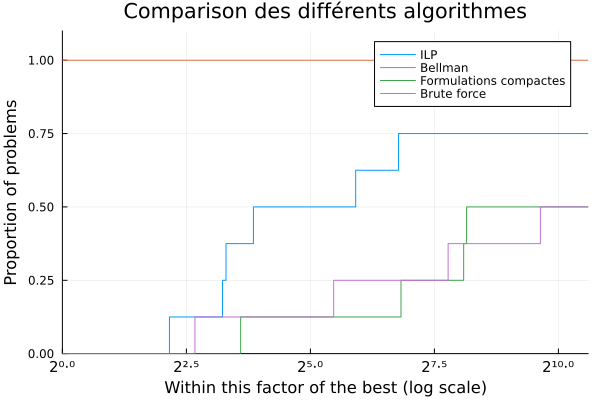

In [15]:
T = [times[1] times[2] times[3] times[4]]
performance_profile(PlotsBackend(), T, ["ILP", "Bellman", "Formulations compactes", "Brute force"], title="Comparison des différents algorithmes")